Основная информация по отчету
ФИО - Быков Владимир Андреевич
ИСУ - 465327
Практический поток - ИИИ 2.2

In [23]:
import numpy as np
import matplotlib.pyplot as plt

генерируем случайные числа и считаем расстояние от каждой точки.

In [24]:
a = 1
num_radii = 5
radii = [a / (k + 1) for k in range(num_radii)]
N_max = 100000

np.random.seed(9045)
x = np.random.uniform(-a, a, N_max)
y = np.random.uniform(-a, a, N_max)
d = np.sqrt(x**2 + y**2)

Снизу визуализация задачи геометрической вероятности. Он показывает, как случайные точки распределяются внутри квадрата и круга, чтобы наглядно продемонстрировать суть метода Монте-Карло. Сначала выбирается конкретный радиус круга для примера (r_example = 0.5) и создается маска точек, которые попадают в этот круг (mask_example = d <= r_example).Затем настраивается график:

Создается фигура с квадратными осями, чтобы сохранить правильные пропорции, а аткже красный круг, который помогает наглядно показать таргеты

Главная цель этого блока показать как работает основной принцип геометрической (равна отношению площади круга к площади квадрата). 
Визуализация помогает убедиться, что точки распределены равномерно и расчеты будут корректными.

Такой график полезен для: проверки правильности генерации точек, понимания сути задачи, демонстрации работы метода Монте-Карло, визуальной оценки соотношения площадей круга и квадрата

Хочется отдельно заметить, что необходимо использование именно рандомных точек тк определенная закономерность(я например, хотел сделать так, чтобы в центре точек было чуть больше) может нарушить метод монте карло

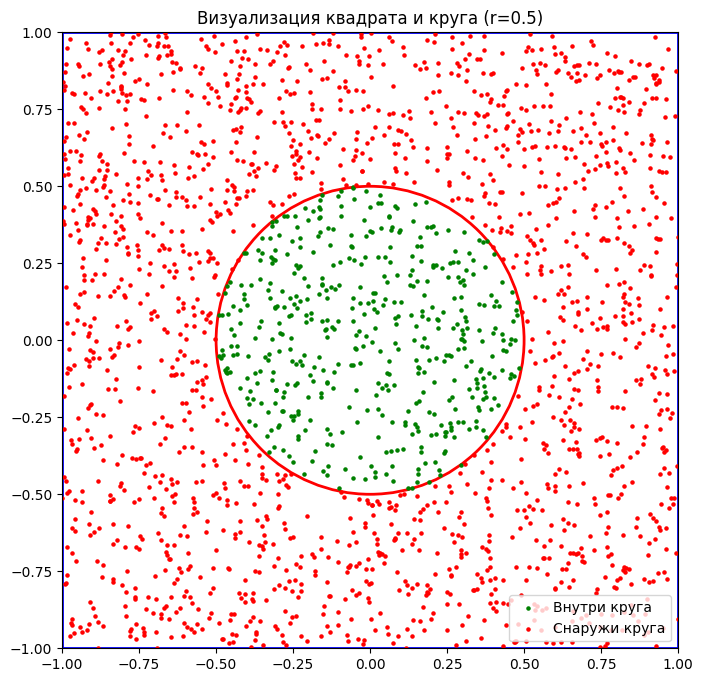

In [25]:
r_example = 0.5
mask_example = d <= r_example

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-a, a)
ax.set_ylim(-a, a)
ax.set_aspect('equal')

rect = plt.Rectangle((-a, -a), 2*a, 2*a, fill=False, edgecolor='blue', linewidth=2)
ax.add_patch(rect)

circle = plt.Circle((0, 0), r_example, fill=False, edgecolor='red', linewidth=2)
ax.add_patch(circle)

sample_size = 2300
x_sample = x[:sample_size]
y_sample = y[:sample_size]
mask = d[:sample_size] <= r_example

ax.scatter(x_sample[mask], y_sample[mask], color='green', s=5, label='Внутри круга')
ax.scatter(x_sample[~mask], y_sample[~mask], color='red', s=5, label='Снаружи круга')
plt.title(f'Визуализация квадрата и круга (r={r_example})')
plt.legend()
plt.show()

Снизу вычисляются точные значения вероятности попадания точки в круг для каждого заданного радиуса. Он использует формулу отношения площади круга к площади квадрата: (πr²)/(4a²). Значения сохраняются в списке p_values и служат для сравнения с результатами моделирования методом Монте-Карло.

In [26]:
p_values = [np.pi * r**2 / (4 * a**2) for r in radii]

Метод Монте-Карло для оценки геометрической вероятности. Метод Монте-Карло - это способ решения задач через случайные выборки
1 генерируем много случайных точек
2 проверяем условие (попадание в круг) 
3 считаем долю успешных исходов

Сначала создается массив с разными количествами точек от 100 до 100000. Для каждого количества точек генерируются случайные координаты в квадрате. Затем для каждого радиуса проверяется, какие точки попали в круг, и считается их доля. Эти данные сохраняются в массив.

Строится 5 графиков (по числу радиусов). На каждом графике синяя линия показывает, как меняется оценка вероятности при увеличении числа точек, а красная пунктирная - истинное значение вероятности. Ось X (количество точек) сделана логарифмической для наглядности.

Код строит два типа графиков для каждого радиуса:

Сходимость оценки к теоретическому значению при увеличении числа точек

Зависимость ошибки оценки от объёма выборки

Видно: что оценка стремится к истинному значению, сколько точек нужно для хорошей точности

Главное преимущество метода - он работает даже для сложных задач, где трудно вычислить точное решение.

Графики используют логарифмические шкалы для наглядного отображения данных на разных масштабах. Визуализация подтверждает, что метод Монте-Карло даёт точные результаты при больших N, при этом ошибка уменьшается пропорционально 1/√N. Для больших радиусов сходимость достигается быстрее.

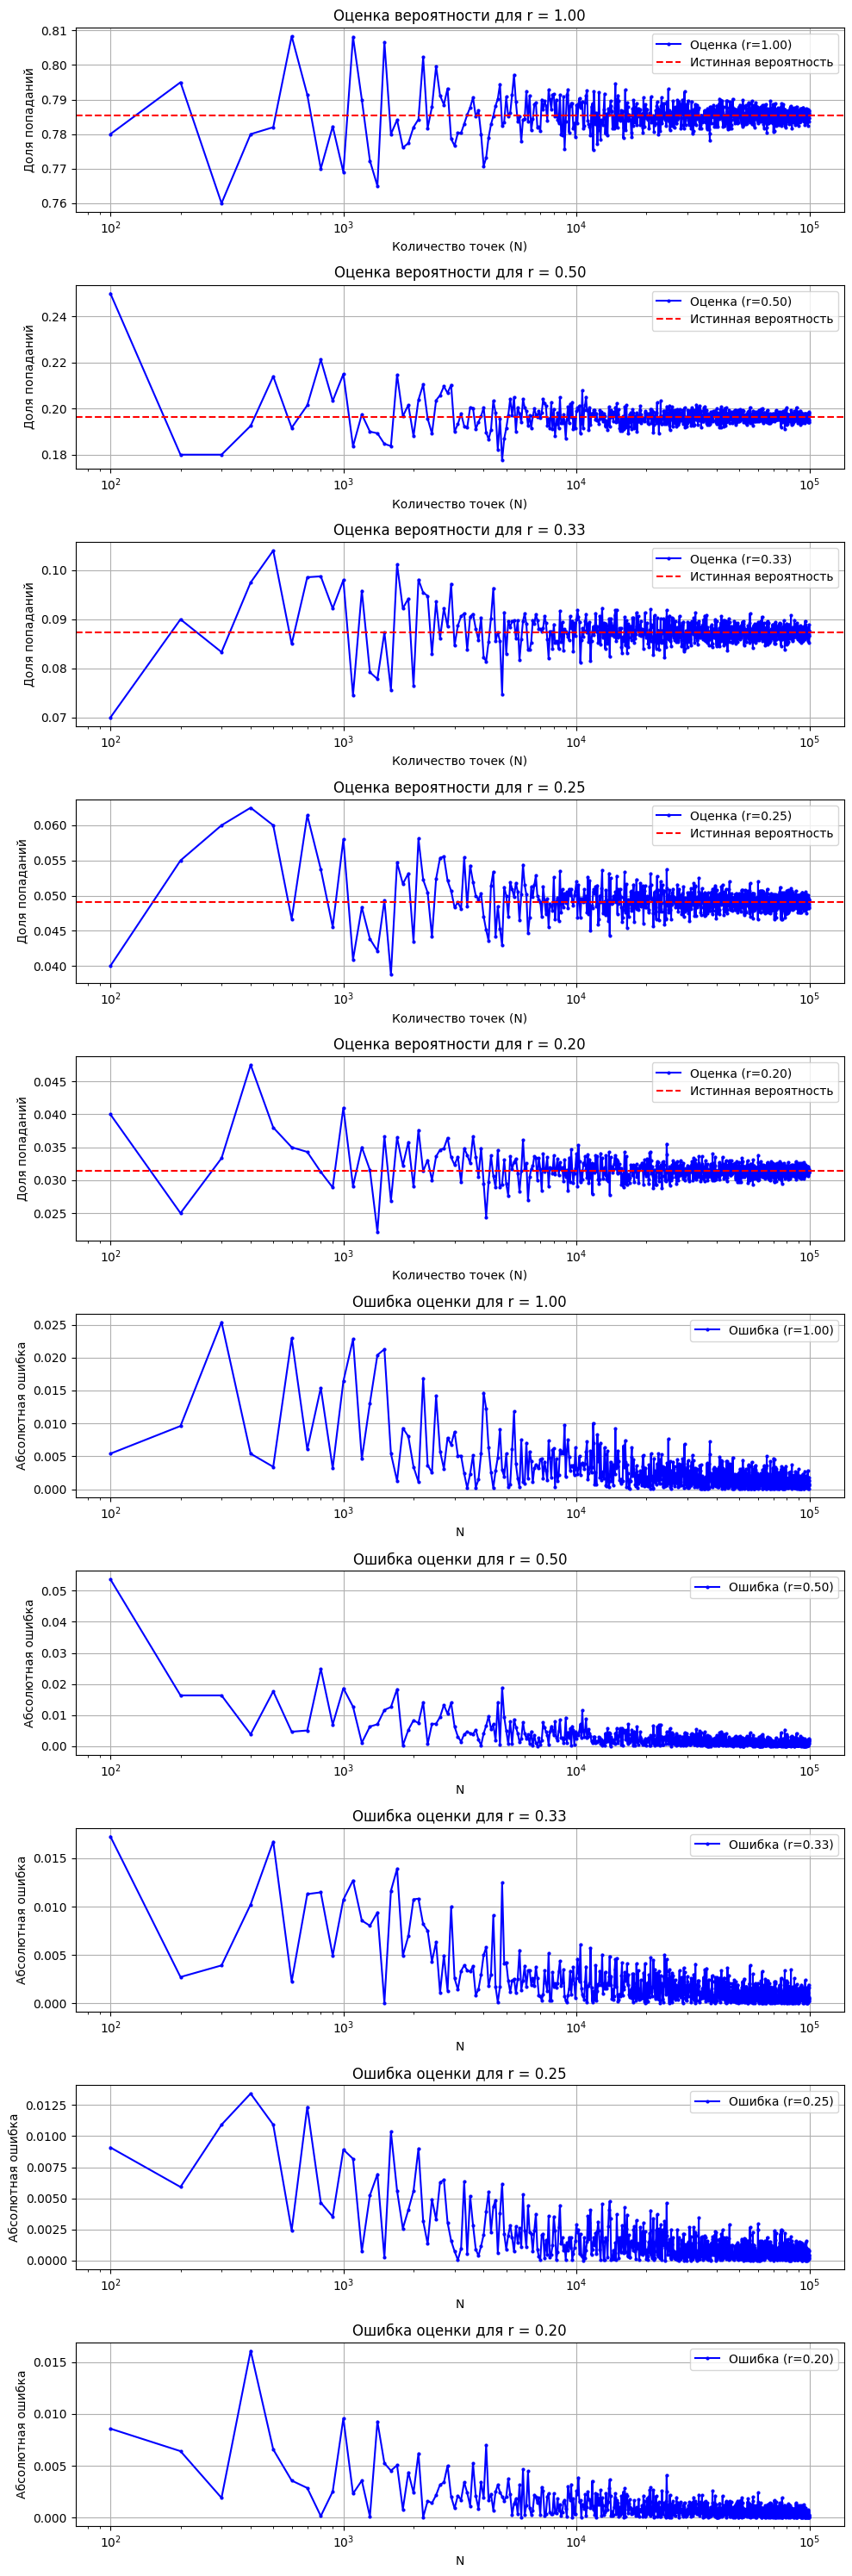

In [ ]:
fig, axs = plt.subplots(nrows=2 * num_radii, ncols=1, figsize=(10, 30))
n_test_array = list(range(100, 100000, 100))
test_hit_point_array = np.zeros((len(n_test_array), num_radii))
random_generator = np.random.default_rng(seed=42)
for j, n in enumerate(n_test_array):
    rand_x = random_generator.uniform(-a, a, n)
    rand_y = random_generator.uniform(-a, a, n)
    for i, r in enumerate(radii):
        mask_inside = rand_x**2 + rand_y**2 <= r**2
        test_hit_point_array[j, i] = np.sum(mask_inside) / n
for i in range(num_radii):
    axs[i].plot(n_test_array, test_hit_point_array[:, i], 
                marker="o", markersize=2, linestyle='-', color='blue', 
                label=f'Оценка (r={radii[i]:.2f})')
    axs[i].axhline(y=p_values[i], color='red', linestyle='--', 
                   label='Истинная вероятность')
    axs[i].set_xlabel('Количество точек (N)')
    axs[i].set_ylabel('Доля попаданий')
    axs[i].set_xscale('log')
    axs[i].set_title(f'Оценка вероятности для r = {radii[i]:.2f}')
    axs[i].legend()
    axs[i].grid(True)
for i in range(num_radii):
    j = i + num_radii
    x_vals = np.array(n_test_array)
    y_vals = np.abs(test_hit_point_array[:, i] - p_values[i])
    axs[j].plot(x_vals, y_vals, marker="o", markersize=2, color="b", 
                label=f"Ошибка (r={radii[i]:.2f})")
    axs[j].set_xlabel("N")
    axs[j].set_ylabel("Абсолютная ошибка")
    axs[j].set_title(f"Ошибка оценки для r = {radii[i]:.2f}")
    axs[j].set_xscale("log")
    axs[j].legend()
    axs[j].grid(True)

plt.tight_layout()
plt.show()

По графикам выше видно, что доля попаданий приближается к истинной вероятност. Оценка ошибки для r также падает, что подтверждает предположение

Анализ точности метода Монте-Карло при оценке геометрической вероятности для разных радиусов круга. 
Задает список значений точности (epsilon_i_list) от 0.1 до 0.0001

Для каждого радиуса из списка radii:
Определяет, какие точки попали в круг данного радиуса
Считает накопленное количество попаданий
Вычисляет оценку вероятности и ошибку относительно теоретического значения
Находит минимальное количество точек, необходимое для достижения каждой заданной точности
Строит график в логарифмическом масштабе, который показывает:
По горизонтальной оси - требуемую точность (ε)
По вертикальной оси - необходимое количество точек (N)
Отдельные линии для каждого радиуса

Основное назначение этого кода - исследовать зависимость между:
Требуемой точностью расчета
Необходимым объемом вычислений (количеством точек)
Размером анализируемой области (радиусом круга)
График позволяет наглядно увидеть:
Что для больших радиусов требуется меньше точек для достижения той же точности
Как резко возрастает необходимое количество точек при увеличении точности
Практические ограничения метода Монте-Карло при работе с разными размерами областей

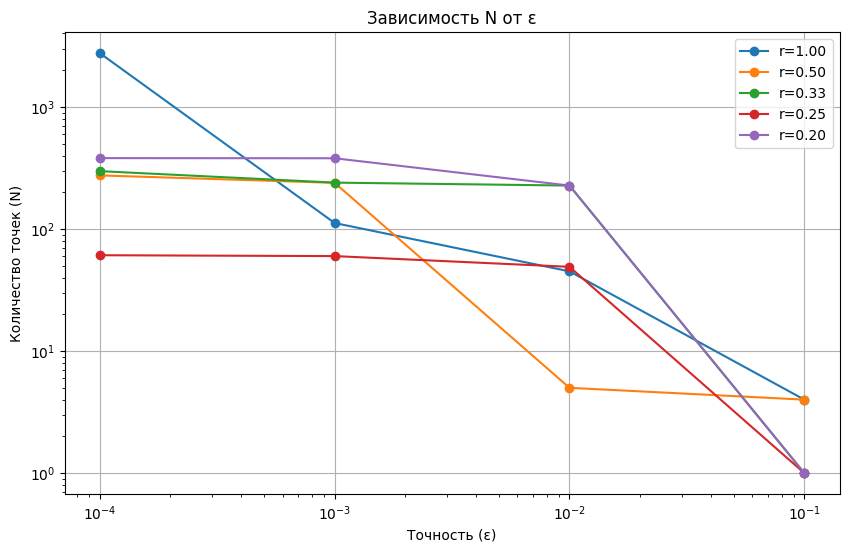

In [28]:
epsilon_i_list = [0.1, 0.01, 0.001, 0.0001]
plt.figure(figsize=(10, 6))

for i, r in enumerate(radii):
    mask = d <= r
    cumulative_hits = np.cumsum(mask)
    hat_p = cumulative_hits / np.arange(1, N_max + 1)
    epsilon = np.abs(hat_p - p_values[i])
    
    N_values = []
    for eps in epsilon_i_list:
        indices = np.where(epsilon <= eps)[0]
        N = indices[0] + 1 if len(indices) > 0 else N_max
        N_values.append(N)
    
    plt.plot(epsilon_i_list, N_values, marker='o', label=f'r={r:.2f}')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Точность (ε)')
plt.ylabel('Количество точек (N)')
plt.title('Зависимость N от ε')
plt.legend()
plt.grid(True)
plt.show()

По оси X: Требуемая точность ε

По оси Y: Количество точек N, необходимое для достижения этой точности

Линии: Для каждого радиуса r своя кривая, показывающая, как быстро метод сходится к истинному значению.

Выводы

(1) Чем выше точность (меньше ε), тем больше точек N требуется
Например, для ε=0.1 может хватить N=100, а для ε=0.0001 уже N=100,000.
Это соответствует теоретическому свойству метода Монте-Карло: ошибка уменьшается как ∼1/√N.
(2) Для больших радиусов r нужно меньше точек
Кривые для больших r (например, r=0.50) расположены ниже, чем для малых (r=0.20).
Причина: В большой круг попадает больше точек, поэтому оценка стабилизируется быстрее.
(3) Логарифмическая зависимость
График в лог. масштабе показывает линейную тенденцию (для метода Монте-Карло это ожидаемо).
Если наклон кривой ≈ -2, это соответствует закону 1/√N (так как log(ε) ≈ -0.5·log(N)).